In [29]:
import pandas as pd

data = pd.read_csv("data/diabetes.csv")
print(data)
print(len(data))
print(data['Pregnancies'])
print(data.keys())
print(data.shape)
print(data.info())
print(data.describe())

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [30]:
data['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

empty_rows = data.isnull().sum()
print(empty_rows)

for feature in data.keys():
    zero_rows = (data[feature] == 0).sum()
    print(f"{feature}: {str(zero_rows)}")

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Pregnancies: 111
Glucose: 0
BloodPressure: 0
SkinThickness: 0
Insulin: 0
BMI: 0
DiabetesPedigreeFunction: 0
Age: 0
Outcome: 500


In [32]:
columns_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("hello")
for col in columns_to_fix:
    med = data[data[col] != 0][col].median() # non zero median
    data[col] = data[col].replace(0, med)

    print(f"{col}: replaced zeros with {med}")

hello
Glucose: replaced zeros with 117.0
BloodPressure: replaced zeros with 72.0
SkinThickness: replaced zeros with 29.0
Insulin: replaced zeros with 125.0
BMI: replaced zeros with 32.3


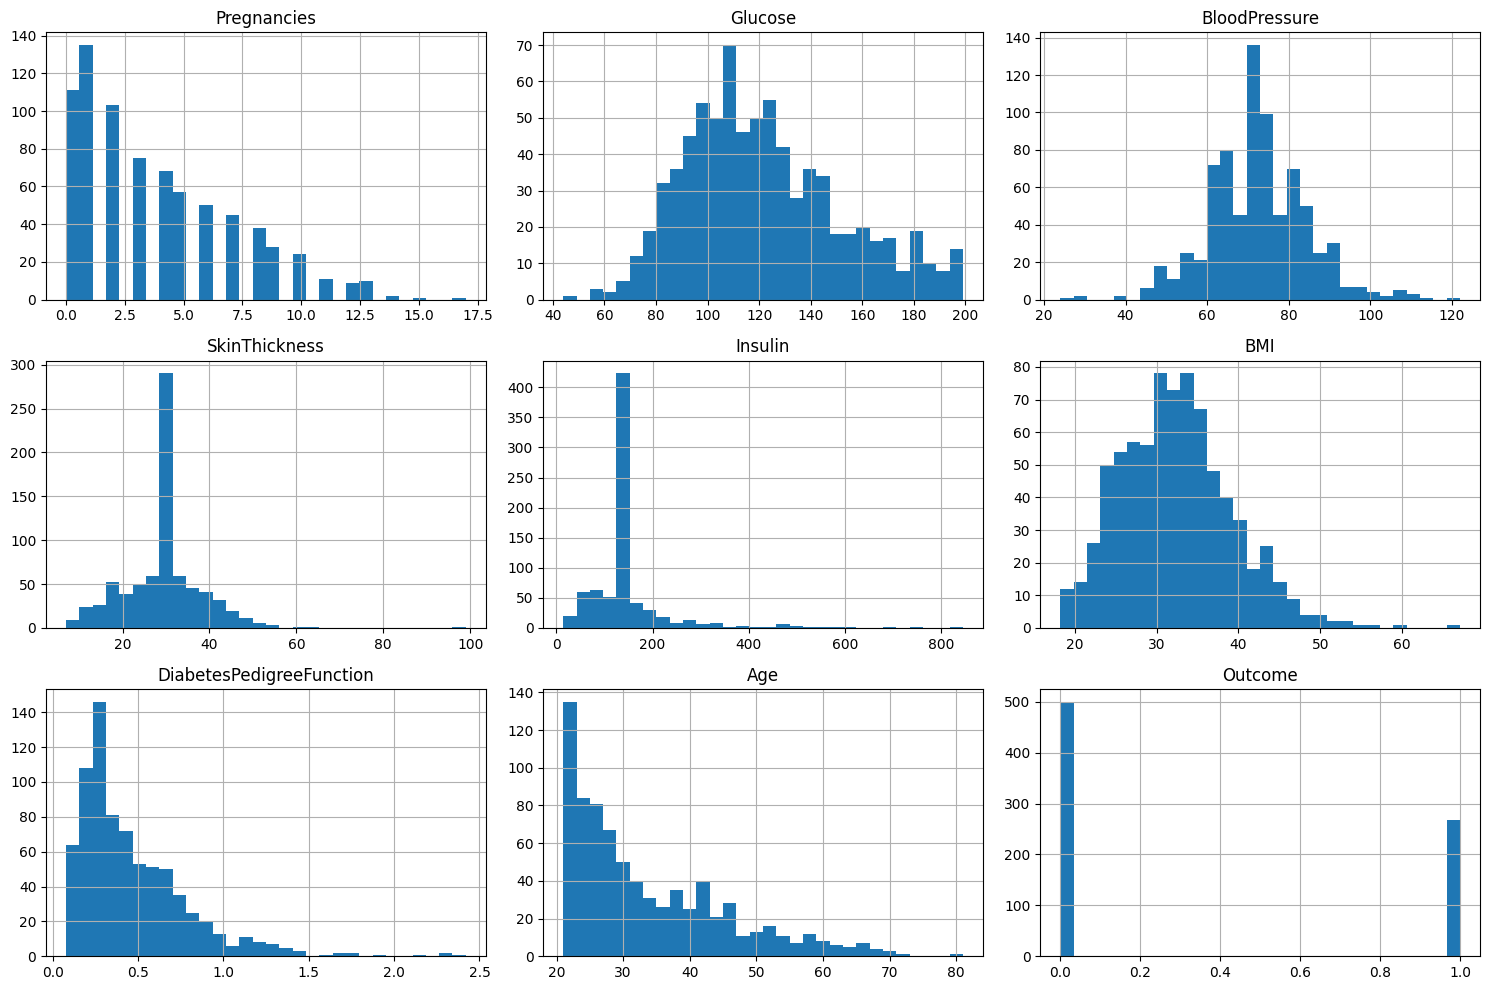

In [34]:
data.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

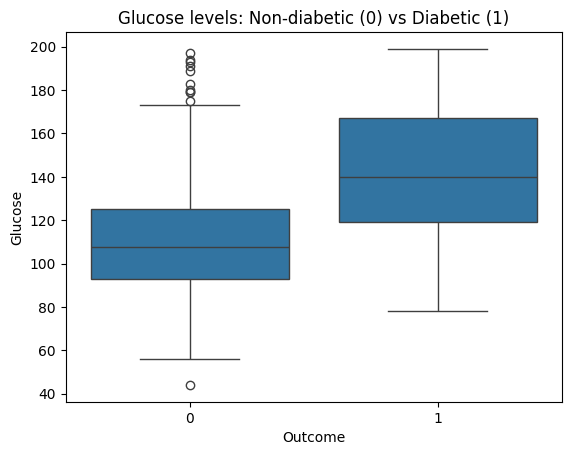

In [35]:
sns.boxplot(x='Outcome', y='Glucose', data=data)
plt.title('Glucose levels: Non-diabetic (0) vs Diabetic (1)')
plt.show()

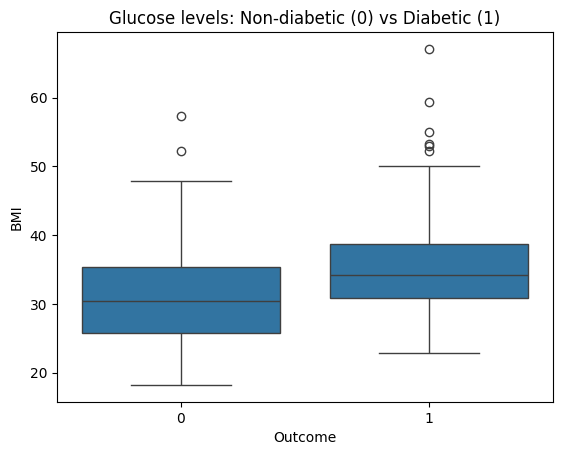

In [36]:
sns.boxplot(x='Outcome', y='BMI', data=data)
plt.title('Glucose levels: Non-diabetic (0) vs Diabetic (1)')
plt.show()

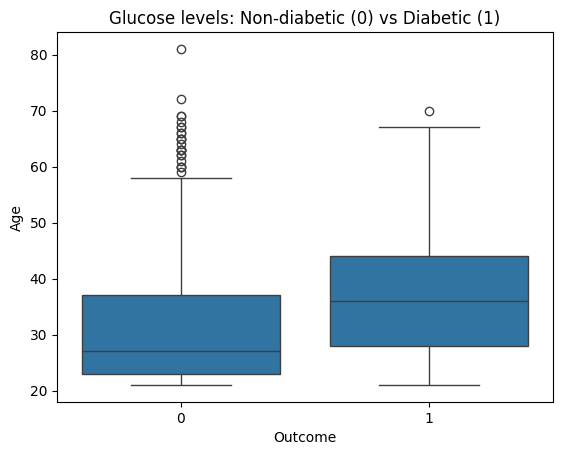

In [37]:
sns.boxplot(x='Outcome', y='Age', data=data)
plt.title('Glucose levels: Non-diabetic (0) vs Diabetic (1)')
plt.show()

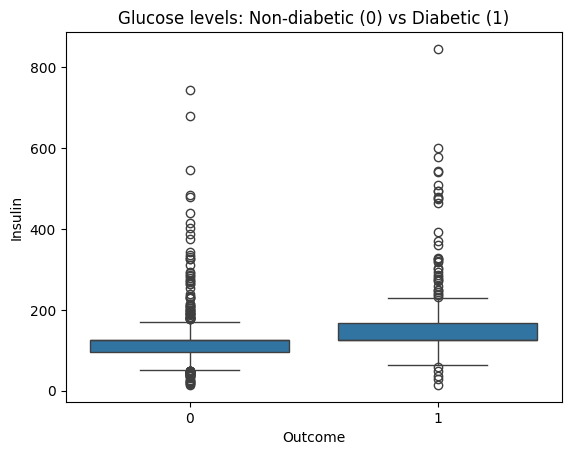

In [38]:
sns.boxplot(x='Outcome', y='Insulin', data=data)
plt.title('Glucose levels: Non-diabetic (0) vs Diabetic (1)')
plt.show()

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data.loc[:, data.columns != 'Outcome']
y = data['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
print(X_train.head())
print(f"X_train size: {len(X_train)}")
print(X_test.head())
print(f"X_test size: {len(X_test)}")
print(y_train.head())
print(f"y_train size: {len(y_train)}")
print(y_test.head())
print(f"y_test size: {len(y_test)}")

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
60             2       84             72             29      125  32.3   
618            9      112             82             24      125  28.2   
346            1      139             46             19       83  28.7   
294            0      161             50             29      125  21.9   
231            6      134             80             37      370  46.2   

     DiabetesPedigreeFunction  Age  
60                      0.304   21  
618                     1.282   50  
346                     0.654   22  
294                     0.254   65  
231                     0.238   46  
X_train size: 614
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
668            6       98             58             33      190  34.0   
324            2      112             75             32      125  35.7   
624            2      108             64             29      125  30.8   
690            8   

In [49]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Mean of X_train: {X_train_scaled.mean(axis=0)}")
print(f"Std of X_train: {X_train_scaled.std(axis=0)}")

Mean of X_train: [ 1.73585359e-17  9.83650367e-17 -1.15723573e-17  1.41761376e-16
 -1.43207921e-16 -3.70315432e-16  1.56226823e-16 -3.76101611e-17]
Std of X_train: [1. 1. 1. 1. 1. 1. 1. 1.]


In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

log_accuracy = accuracy_score(y_test, y_pred_log)
print(f"Accuracy score: {log_accuracy:.3f}")

Accuracy score: 0.753


In [75]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy score: {dt_accuracy:.3f}")

Accuracy score: 0.714


In [76]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, n_estimators=120)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy score: {rf_accuracy:.3f}")

Accuracy score: 0.760


In [77]:
from sklearn.neighbors import KNeighborsClassifier

kn_model = KNeighborsClassifier(n_neighbors=10)
kn_model.fit(X_train_scaled, y_train)
y_pred_kn = kn_model.predict(X_test_scaled)

kn_accuracy = accuracy_score(y_test, y_pred_kn)
print(f"Accuracy score: {kn_accuracy:.3f}")

Accuracy score: 0.760


In [73]:
print("Model Comparison:")
print(f"Logistic Regression: {log_accuracy:.3f}")
print(f"Decision Tree:       {dt_accuracy:.3f}")
print(f"Random Forest:       {rf_accuracy:.3f}")
print(f"KNN:                 {kn_accuracy:.3f}")

Model Comparison:
Logistic Regression: 0.753
Decision Tree:       0.714
Random Forest:       0.760
KNN:                 0.760


In [81]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf_cm = confusion_matrix(y_test, y_pred_rf)
print("Random Forest Confusion Matrix")
print(rf_cm)
print(classification_report(y_test, y_pred_rf))

kn_cm = confusion_matrix(y_test, y_pred_kn)
print("KNeighbors Confusion Matrix")
print(kn_cm)
print(classification_report(y_test, y_pred_kn))

Random Forest Confusion Matrix
[[79 20]
 [17 38]]
              precision    recall  f1-score   support

           0       0.82      0.80      0.81        99
           1       0.66      0.69      0.67        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154

KNeighbors Confusion Matrix
[[85 14]
 [23 32]]
              precision    recall  f1-score   support

           0       0.79      0.86      0.82        99
           1       0.70      0.58      0.63        55

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.75       154



In [85]:
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"Random Forest AUC: {auc_rf:.3f}")

y_pred_proba_kn = kn_model.predict_proba(X_test_scaled)[:, 1]
auc_kn = roc_auc_score(y_test, y_pred_proba_kn)
print(f"KNeighbors AUC: {auc_kn:.3f}")

Random Forest AUC: 0.834
KNeighbors AUC: 0.801


In [87]:
importances = rf_model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)
print(importance_df)

                    Feature  Importance
1                   Glucose    0.259041
5                       BMI    0.163190
7                       Age    0.136944
6  DiabetesPedigreeFunction    0.121152
4                   Insulin    0.090766
2             BloodPressure    0.082851
3             SkinThickness    0.073503
0               Pregnancies    0.072554


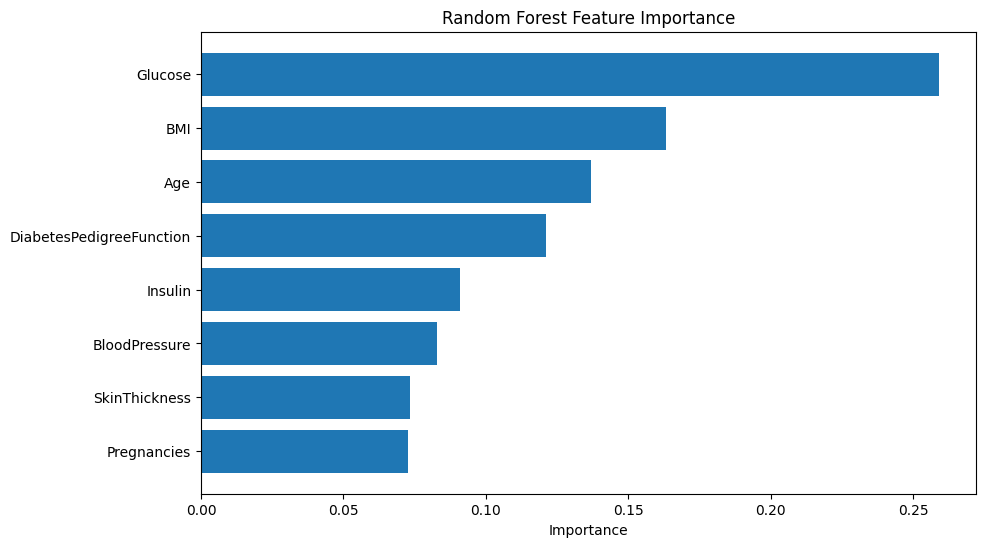

In [88]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()  # Highest at top
plt.show()

In [95]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 150, 120],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_scaled, y_train)
print(f"Best params: {grid_search.best_params_}")
print(f"Best auc scores: {grid_search.best_score_}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
Best auc scores: 0.8407603085736159


In [103]:
new_rf_model = grid_search.best_estimator_
new_rf_model.fit(X_train_scaled, y_train)
new_y_pred_rf = new_rf_model.predict(X_test_scaled)

new_rf_accuracy = accuracy_score(y_test, new_y_pred_rf)
print(f"Accuracy score: {new_rf_accuracy:.3f}")

new_y_pred_proba_rf = new_rf_model.predict_proba(X_test_scaled)[:, 1]
new_auc_rf = roc_auc_score(y_test, new_y_pred_proba_rf)
print(f"Random Forest AUC: {new_auc_rf:.3f}")

new_rf_cm = confusion_matrix(y_test, new_y_pred_rf)
print("Random Forest Confusion Matrix")
print(new_rf_cm)
print(classification_report(y_test, new_y_pred_rf))

Accuracy score: 0.766
Random Forest AUC: 0.846
Random Forest Confusion Matrix
[[80 19]
 [17 38]]
              precision    recall  f1-score   support

           0       0.82      0.81      0.82        99
           1       0.67      0.69      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



In [102]:
weighted_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)

weighted_rf.fit(X_train_scaled, y_train)

weighted_y_pred_rf = weighted_rf.predict(X_test_scaled)
weighted_rf_accuracy = accuracy_score(y_test, weighted_y_pred_rf)
print(f"Accuracy score: {weighted_rf_accuracy:.3f}")

weighted_y_pred_proba_rf = weighted_rf.predict_proba(X_test_scaled)[:, 1]
weighted_auc_rf = roc_auc_score(y_test, weighted_y_pred_proba_rf)
print(f"Random Forest AUC: {weighted_auc_rf:.3f}")

weighted_rf_cm = confusion_matrix(y_test, weighted_y_pred_rf)
print("Random Forest Confusion Matrix")
print(weighted_rf_cm)
print(classification_report(y_test, weighted_y_pred_rf))

Accuracy score: 0.766
Random Forest AUC: 0.840
Random Forest Confusion Matrix
[[75 24]
 [12 43]]
              precision    recall  f1-score   support

           0       0.86      0.76      0.81        99
           1       0.64      0.78      0.70        55

    accuracy                           0.77       154
   macro avg       0.75      0.77      0.76       154
weighted avg       0.78      0.77      0.77       154



In [108]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"Before SMOTE: {y_train.value_counts()}")
print(f"After SMOTE: {pd.Series(y_train_smote).value_counts()}")

Before SMOTE: Outcome
0    401
1    213
Name: count, dtype: int64
After SMOTE: Outcome
0    401
1    401
Name: count, dtype: int64


In [111]:
smote_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    random_state=42
)

smote_rf.fit(X_train_smote, y_train_smote)
y_pred_smote = smote_rf.predict(X_test_scaled)
y_pred_proba_smote = smote_rf.predict_proba(X_test_scaled)[:, 1]

smote_accuracy = accuracy_score(y_test, y_pred_smote)
smote_auc = roc_auc_score(y_test, y_pred_proba_smote)
smote_cm = confusion_matrix(y_test, y_pred_smote)

print(f"Accuracy: {smote_accuracy:.3f}")
print(f"AUC: {smote_auc:.3f}")
print("Confusion Matrix")
print(smote_cm)
print("Classification report")
print(classification_report(y_test, y_pred_smote))

Accuracy: 0.753
AUC: 0.835
Confusion Matrix
[[74 25]
 [13 42]]
Classification report
              precision    recall  f1-score   support

           0       0.85      0.75      0.80        99
           1       0.63      0.76      0.69        55

    accuracy                           0.75       154
   macro avg       0.74      0.76      0.74       154
weighted avg       0.77      0.75      0.76       154

